In [ ]:
!pip install tabulate


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate

%matplotlib inline


In [2]:
df = pd.read_pickle("../assets/data/villanova-kepler-binaries-lcs.pkl")


In [3]:
# print(tabulate(df, headers='keys', tablefmt='rst'))


In [4]:
# print(tabulate(df, headers='keys', tablefmt='simple_grid'))


In [5]:
df.head(15)


,index,period,period_err,bjd0,bjd0_err,morph,GLon,GLat,kmag,Teff,SC,time,flux,flux_err,n_points
KIC,,,,,,,,,,,,,,,
3863594,0,0.053268,0.000000e+00,55000.000000,0.004327,0.79,-1.0000,-1.0000,-1.000,-1.0,False,"[120.53895485026442, 120.55938947320828, 120.5...","[1.0027486085891724, 0.9967120885848999, 0.999...","[9.64640494203195e-05, 9.793051140150055e-05, ...",52286
10417986,1,0.073731,0.000000e+00,55000.027476,0.004231,0.99,81.0390,11.0820,9.128,-1.0,True,"[120.53855550513981, 120.55898988617264, 120.5...","[0.999791145324707, 0.9999734163284302, 0.9995...","[1.373476243315963e-05, 1.3659494470630307e-05...",52200
8912468,2,0.094838,0.000000e+00,54953.576945,0.005326,0.98,80.1095,7.8882,11.751,6194.0,False,"[120.53837293142715, 120.55880740127031, 120.5...","[0.9991673827171326, 0.9996739625930786, 0.995...","[5.4617426940239966e-05, 5.44519534741994e-05,...",65266
8758716,3,0.107205,0.000000e+00,54953.672989,0.006197,1.00,77.7478,11.6565,13.531,-1.0,False,"[120.53883156277152, 120.55926600434032, 120.5...","[1.0111474990844727, 0.9915452003479004, 1.001...","[0.00011227018694626167, 0.0001110159646486863...",65262
10855535,4,0.112782,0.000000e+00,54964.629315,0.006374,0.99,79.3949,15.9212,13.870,7555.0,False,"[131.51221361904754, 131.5326480107833, 131.55...","[0.9962518215179443, 1.0047160387039185, 1.005...","[0.00015937240095809102, 0.0001598708040546625...",64793
9472174,5,0.125765,1.000000e-07,54953.643178,0.018318,0.78,79.0187,11.6745,12.264,10645.0,True,"[120.53873908418609, 120.55917349758238, 120.5...","[0.9766239523887634, 0.9745587706565857, 1.014...","[6.300036329776049e-05, 6.46721528028138e-05, ...",65262
9612468,6,0.133471,1.000000e-07,54953.603803,0.007796,0.99,81.0112,8.5285,11.531,7202.0,False,"[120.53835217891174, 120.55878661484894, 120.5...","[0.999556303024292, 0.999701201915741, 1.00001...","[4.825793803320266e-05, 4.807007280760445e-05,...",65266
6613627,7,0.150800,1.000000e-07,55115.344848,0.008552,0.98,75.1606,10.2517,12.548,7090.0,False,"[120.53893169508228, 120.55936622250738, 120.5...","[0.9986772537231445, 0.9994301199913025, 0.997...","[6.944619963178411e-05, 6.992976705078036e-05,...",65262
5302006,8,0.151171,1.000000e-07,54980.509040,0.007895,0.97,75.3495,6.6449,15.050,6536.0,False,"[131.512027738936, 131.53246243730973, 131.552...","[0.9980388283729553, 1.000171184539795, 0.9940...","[0.0003836112155113369, 0.00038473118911497295...",64797


In [6]:
df.index.name


'KIC'

---

In [7]:
def plotLightCurve(df, kic, with_error=True):
    if kic not in df.index:
        raise ValueError(f"KIC {kic} not found in DataFrame index.")

    row = df.loc[kic]

    t = row["time"]
    f = row["flux"]
    e = row["flux_err"]

    plt.figure(figsize=(20, 5))

    if with_error and e is not None:
        plt.errorbar(t, f, yerr=e, fmt='-', linewidth=1)
    else:
        plt.plot(t, f, linewidth=1)

    plt.xlabel("Time")
    plt.ylabel(r"Normalized Flux (e$^{-}$ s$^{-1}$)")
    plt.title(f"KIC {kic} Light Curve")
    plt.show()
    

---

In [8]:
sampleKIC = df.sample(n = 1).index[0]
sampleKIC


np.int64(8380743)

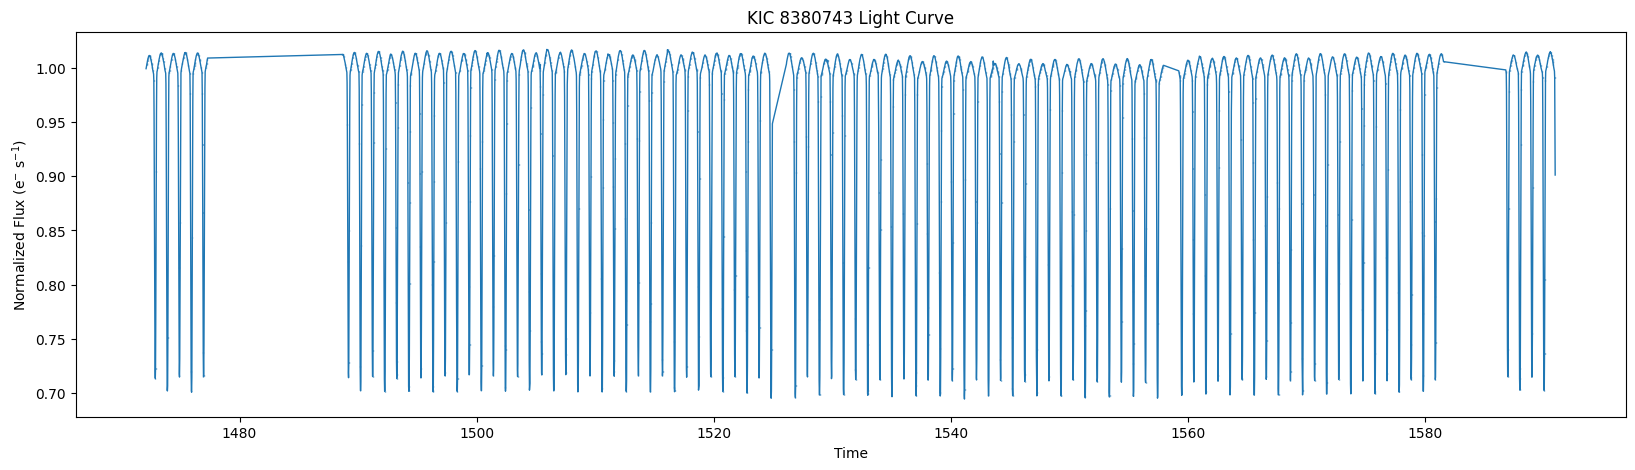

In [9]:
plotLightCurve(df, kic=sampleKIC)
